## Multiple inputs / outputs

So far our neural network has had a single scalar input $x$ and a single scalar output $y$.

However, more generally neural networks map multivariate inputs $$x = [x_1,x_2,...,x_{D_i} ]^{T}$$ to multivariate output
predictions $$y = [y_1,y_2,...,y_{D_o} ]^T$$ 

Note that $D_i$ represents the number of inputs and $D_o$ represents the number of outputs. $D$ is the number of hidden units. 

Here we explore how to extend the model to predict multivariate inputs and outputs. 

<br/>

### Multiple outputs

<br/>

To extend the network to multivariate outputs $y$, we simply use a different linear function
of the hidden units for each output. 

So, a network with a scalar input x, four hidden units $h_1$, $h_2$ , $h_3$, and $h_4$, and a 2D multivariate output $y = [y_1,y_2]^T$ would be defined as:


\begin{eqnarray}\label{eq:snn_multiple_out2}
 h_{1} &=& \mbox{a}[\theta_{10} + \theta_{11}x] \nonumber \\
 h_{2} &=& \mbox{a}[\theta_{20} + \theta_{21}x] \nonumber \\
 h_{3} &=& \mbox{a}[\theta_{30} + \theta_{31}x] \nonumber \\
 h_{4} &=& \mbox{a}[\theta_{40} + \theta_{41}x],
 \end{eqnarray}

\begin{eqnarray}\label{eq:snn_multiple_out1}
 y_1 &=& \phi_{10}+\phi_{11}h_{1}+\phi_{12}h_{2}+\phi_{13}h_{3}+\phi_{14}h_{4}\nonumber \\
 y_2 &=& \phi_{20}+\phi_{21}h_{1}+\phi_{22}h_{2}+\phi_{23}h_{3}+\phi_{24}h_{4}.
 \end{eqnarray}


<img src="assets/Chap03/ShallowNetTwoOutputs.svg" style="filter: invert(1);" width="100%">

Network with one input, four hidden units, and two outputs. a) Visualization of network structure. b) This network produces two piecewise linear functions, y1[x] and y2[x]. The four “joints” of these functions (at vertical dotted
lines) are constrained to be in the same places since they share the same hidden units, but the slopes and overall height may differ.

As we saw in figure 3.3, the “joints” in the piecewise functions depend on where the
initial linear functions θ•0 + θ•1x are clipped by the ReLU functions a[•] at the hidden
units. Since both outputs y1 and y2 are different linear functions of the same four hidden units, the four “joints” in each must be in the same places. However, the slopes of the
linear regions and the overall vertical offset can differ




In [52]:
# Plot the shallow neural network.  We'll assume input in is range [0,10],[0,10] and output [-10,10]
def plot_neural_2_inputs_2_outputs(x1,x2, y1, y2, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_11, w_act_12, w_act_13, w_act_21, w_act_22, w_act_23):

  # Plot intermediate plots if flag set
  fig, ax = plt.subplots(4,3)
  fig.set_size_inches(8.5, 8.5)
  fig.tight_layout(pad=3.0)
  ax[0, 0].plot(x1, pre_1); ax[0, 0].set_title('Preactivation')
  # draw_2D_function(ax[0,0], x1,x2,pre_1); ax[0,0].set_title('Preactivation')
  ax[0,1].plot(x1,pre_2); ax[0,1].set_title('Preactivation')
  ax[0,2].plot(x1,pre_3); ax[0,2].set_title('Preactivation')
  ax[1,0].plot(x1,act_1); ax[1,0].set_title('Activation $h_1$')
  ax[1,1].plot(x1,act_2); ax[1,1].set_title('Activation $h_2$')
  ax[1,2].plot(x1,act_3); ax[1,2].set_title('Activation $h_3$')
  ax[2,0].plot(x1,w_act_11, c='blue'); ax[2,0].set_title('Weighted Act 11 $\phi_{11} h_1$')
  ax[2,1].plot(x1,w_act_12, c='blue'); ax[2,1].set_title('Weighted Act 12 $\phi_{12} h_2$')
  ax[2,2].plot(x1,w_act_13, c='blue'); ax[2,2].set_title('Weighted Act 13 $\phi_{13} h_3$')
  ax[3,0].plot(x1,w_act_21, c='orange'); ax[3,0].set_title('Weighted Act 21  $\phi_{21} h_1$')
  ax[3,2].plot(x1,w_act_23, c='orange'); ax[3,2].set_title('Weighted Act 22  $\phi_{22} h_2$')
  ax[3,1].plot(x1,w_act_22, c='orange'); ax[3,1].set_title('Weighted Act 23  $\phi_{23} h_3$')
  plt.show()

  fig, ax = plt.subplots(figsize=(6, 3))
  ax.plot(x1,y1, c='blue')
  # ax.set_title('Network output, $y$')
  # ax.set_aspect(1.0)
  # plt.show()

  # fig, ax = plt.subplots()
  # draw_2D_function(ax,x1,x2,y2)
  ax.plot(x2,y2, c='orange')
  ax.set_title('Network outputs, $y_1$ and $y_2$')
  plt.show()
     

In [53]:
# Define a shallow neural network with, two inputs, two outputs, and three hidden units
def shallow_1_2_3(x1, activation_fn, phi_10,phi_11,phi_12,phi_13, phi_20,phi_21,phi_22,phi_23, theta_10, theta_11,\
                  theta_20, theta_21, theta_30, theta_31):

  pre_1 = theta_10 + theta_11*x1
  pre_2 = theta_20 + theta_21*x1
  pre_3 = theta_30 + theta_31*x1

  act_1 = activation_fn(pre_1)
  act_2 = activation_fn(pre_2)
  act_3 = activation_fn(pre_3)

  w_act_11 = act_1 * phi_11
  w_act_12 = act_2 * phi_12
  w_act_13 = act_3 * phi_13

  w_act_21 = act_1 * phi_21
  w_act_22 = act_2 * phi_22
  w_act_23 = act_3 * phi_23

  y1 = phi_10 + w_act_11 + w_act_12 + w_act_13
  y2 = phi_20 + w_act_21 + w_act_22 + w_act_23

  return y1,y2, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_11, w_act_12, w_act_13, w_act_21, w_act_22, w_act_23

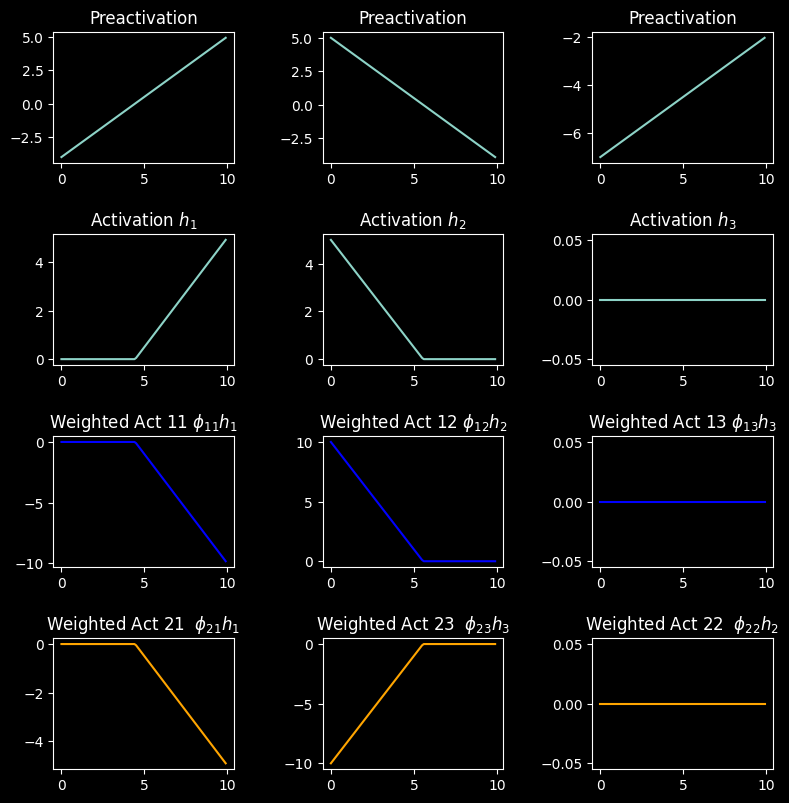

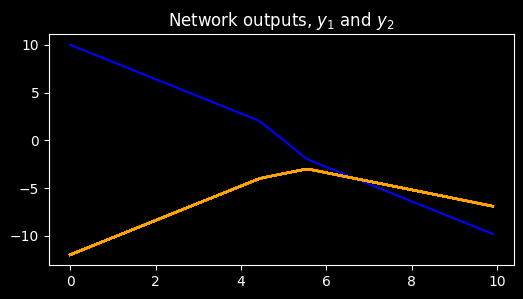

In [54]:
import numpy as np 

# Now lets define some parameters and run the neural network
theta_10 =  -4.0 ;  theta_11 = 0.9; theta_12 = 0.0
theta_20 =  5.0  ; theta_21 = -0.9 ; theta_22 = -0.5
theta_30 =  -7  ; theta_31 = 0.5; theta_32 = 0.9
phi_10 = 0.0; phi_11 = -2.0; phi_12 = 2.0; phi_13 = 1.5
phi_20 = -2.0; phi_21 = -1.0; phi_22 = -2.0; phi_23 = 0.8

x1 = np.arange(0.0, 10.0, 0.1)
# x2 = np.arange(0.0, 10.0, 0.1)
# x1,x2 = np.meshgrid(x1,x2)  # https://www.geeksforgeeks.org/numpy-meshgrid-function/

# We run the neural network for each of these input values
y1, y2, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_11, w_act_12, w_act_13, w_act_21, w_act_22, w_act_23 = \
    shallow_1_2_3(x1, ReLU, phi_10,phi_11,phi_12,phi_13, phi_20,phi_21,phi_22,phi_23, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)
# And then plot it
plot_neural_2_inputs_2_outputs(x1,x2, y1, y2, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_11, w_act_12, w_act_13, w_act_21, w_act_22, w_act_23)

<br/>

### Multiple inputs 
 
<br/>

To cope with multivariate inputs $x$, we extend the linear relations between the input and the hidden units. So a network with two inputs $x = [x_1,x_2]^T$ and a scalar output $y$ might have three hidden units defined by:



\begin{eqnarray}\label{eq:snn_multiple3}
 h_{1} &=& \mbox{a}[\theta_{10} + \theta_{11}x_1+ \theta_{12}x_2] \nonumber \\
 h_{2} &=& \mbox{a}[\theta_{20} + \theta_{21}x_1+\theta_{22}x_2] \nonumber \\
 h_{3} &=& \mbox{a}[\theta_{30} + \theta_{31}x_1+\theta_{32}x_2],
 \end{eqnarray}

where there is now one slope parameter for each input. The hidden units are combined
to form the output in the usual way:

\begin{eqnarray}\label{eq:snn_multiple4}
 y = \phi_{0}+\phi_{1}h_{1}+\phi_{2}h_{2}+\phi_{3}h_{3}.
 \end{eqnarray}

The figure below illustrates the processing of this network. Each hidden unit receives a linear combination of the two inputs, which forms an oriented plane in the 3D input/output
space. 

The activation function clips the negative values of these planes to zero. The
clipped planes are then recombined in a second linear function to create
a continuous piecewise linear surface consisting of convex polygonal regions.

Each region corresponds to a different activation pattern. 

For example, in the central triangular region, the first and third hidden units are active, and the second is inactive.

When there are more than two inputs to the model, it becomes diﬀicult to visualize.

However, the interpretation is similar. The output will be a continuous piecewise linear
function of the input, where the linear regions are now convex polytopes in the multi-
dimensional input space


<img src="assets/Chap03/ShallowNetTwoInputs.svg" style="filter: invert(1);" width="75%">

Visualization of neural network with 2D multivariate input x = [x1, x2]T and scalar output y.


<img src="assets/Chap03/ShallowBuildUp2D.svg" style="filter: invert(1);" width="100%">

Visualization of how a shallow neural network builds up a piecewise linear approximation in 2D.
Processing in network with two inputs x = [x1, x2]T , three hidden units h1, h2, h3, and one output y. a–c) The input to each hidden unit is a
linear function of the two inputs, which corresponds to an oriented plane. Brightness
indicates function output. For example, in panel (a), the brightness represents θ10 + θ11x1 + θ12x2. Thin lines are contours. d–f) Each plane is clipped by the ReLU activation function (cyan lines are equivalent to “joints” in figures 3.3d–
f). g-i) The clipped planes are then weighted, and j) summed together with an offset that determines the overall height of the surface. The result is a continuous surface made up of convex piecewise linear polygonal regions. (Interactive figure)


In [9]:
# Imports math library
import numpy as np
# Imports plotting library
import matplotlib.pyplot as plt

plt.style.use('dark_background')  # Use dark background for plots

In [10]:
# Define the Rectified Linear Unit (ReLU) function
def ReLU(preactivation):
  activation = preactivation.clip(0.0)
  return activation

In [ ]:
# Code to draw 2D function -- read it so you know what is going on, but you don't have to change it
def draw_2D_function(ax, x1_mesh, x2_mesh, y):
    pos = ax.contourf(x1_mesh, x2_mesh, y, levels=256 ,cmap = 'hot', vmin=-10,vmax=10.0)
    ax.set_xlabel('x1');ax.set_ylabel('x2')
    levels = np.arange(-10,10,1.0)
    ax.contour(x1_mesh, x2_mesh, y, levels, cmap='winter')

# Plot the shallow neural network.  We'll assume input in is range [0,10],[0,10] and output [-10,10]
def plot_neural_2_inputs(x1,x2, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3):

  fig, ax = plt.subplots(3,3)
  fig.set_size_inches(8.5, 8.5)
  fig.tight_layout(pad=3.0)
  draw_2D_function(ax[0,0], x1,x2,pre_1); ax[0,0].set_title('Preactivation')
  draw_2D_function(ax[0,1], x1,x2,pre_2); ax[0,1].set_title('Preactivation')
  draw_2D_function(ax[0,2], x1,x2,pre_3); ax[0,2].set_title('Preactivation')
  draw_2D_function(ax[1,0], x1,x2,act_1); ax[1,0].set_title('Activation')
  draw_2D_function(ax[1,1], x1,x2,act_2); ax[1,1].set_title('Activation')
  draw_2D_function(ax[1,2], x1,x2,act_3); ax[1,2].set_title('Activation')
  draw_2D_function(ax[2,0], x1,x2,w_act_1); ax[2,0].set_title('Weighted Act')
  draw_2D_function(ax[2,1], x1,x2,w_act_2); ax[2,1].set_title('Weighted Act')
  draw_2D_function(ax[2,2], x1,x2,w_act_3); ax[2,2].set_title('Weighted Act')
  plt.show()

  fig, ax = plt.subplots()
  draw_2D_function(ax,x1,x2,y)
  ax.set_title('Network output, $y$')
  ax.set_aspect(1.0)
  plt.show()

In [12]:
# Code to draw 2D function -- read it so you know what is going on, but you don't have to change it
def draw_2D_function(ax, x1_mesh, x2_mesh, y):
    pos = ax.contourf(x1_mesh, x2_mesh, y, levels=256 ,cmap = 'hot', vmin=-10,vmax=10.0)
    ax.set_xlabel('x1');ax.set_ylabel('x2')
    levels = np.arange(-10,10,1.0)
    ax.contour(x1_mesh, x2_mesh, y, levels, cmap='winter')

# Plot the shallow neural network.  We'll assume input in is range [0,10],[0,10] and output [-10,10]
def plot_neural_2_inputs(x1,x2, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3):

  fig, ax = plt.subplots(3,3)
  fig.set_size_inches(8.5, 8.5)
  fig.tight_layout(pad=3.0)
  draw_2D_function(ax[0,0], x1,x2,pre_1); ax[0,0].set_title('Preactivation')
  draw_2D_function(ax[0,1], x1,x2,pre_2); ax[0,1].set_title('Preactivation')
  draw_2D_function(ax[0,2], x1,x2,pre_3); ax[0,2].set_title('Preactivation')
  draw_2D_function(ax[1,0], x1,x2,act_1); ax[1,0].set_title('Activation')
  draw_2D_function(ax[1,1], x1,x2,act_2); ax[1,1].set_title('Activation')
  draw_2D_function(ax[1,2], x1,x2,act_3); ax[1,2].set_title('Activation')
  draw_2D_function(ax[2,0], x1,x2,w_act_1); ax[2,0].set_title('Weighted Act')
  draw_2D_function(ax[2,1], x1,x2,w_act_2); ax[2,1].set_title('Weighted Act')
  draw_2D_function(ax[2,2], x1,x2,w_act_3); ax[2,2].set_title('Weighted Act')
  plt.show()

  fig, ax = plt.subplots()
  draw_2D_function(ax,x1,x2,y)
  ax.set_title('Network output, $y$')
  ax.set_aspect(1.0)
  plt.show()

In [55]:
# Define a shallow neural network with, two input, one output, and three hidden units
def shallow_2_1_3(x1,x2, activation_fn, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11,\
                  theta_12, theta_20, theta_21, theta_22, theta_30, theta_31, theta_32):

  pre_1 = theta_10 + theta_11 * x1 + theta_12 * x2
  pre_2 = theta_20 + theta_21 * x1 + theta_22 * x2
  pre_3 = theta_30 + theta_31 * x1 + theta_32 * x2

  act_1 = activation_fn(pre_1)
  act_2 = activation_fn(pre_2)
  act_3 = activation_fn(pre_3)

  w_act_1 = phi_1 * act_1
  w_act_2 = phi_2 * act_2
  w_act_3 = phi_3 * act_3

  y = phi_0 + w_act_1 + w_act_2 + w_act_3

  return y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3

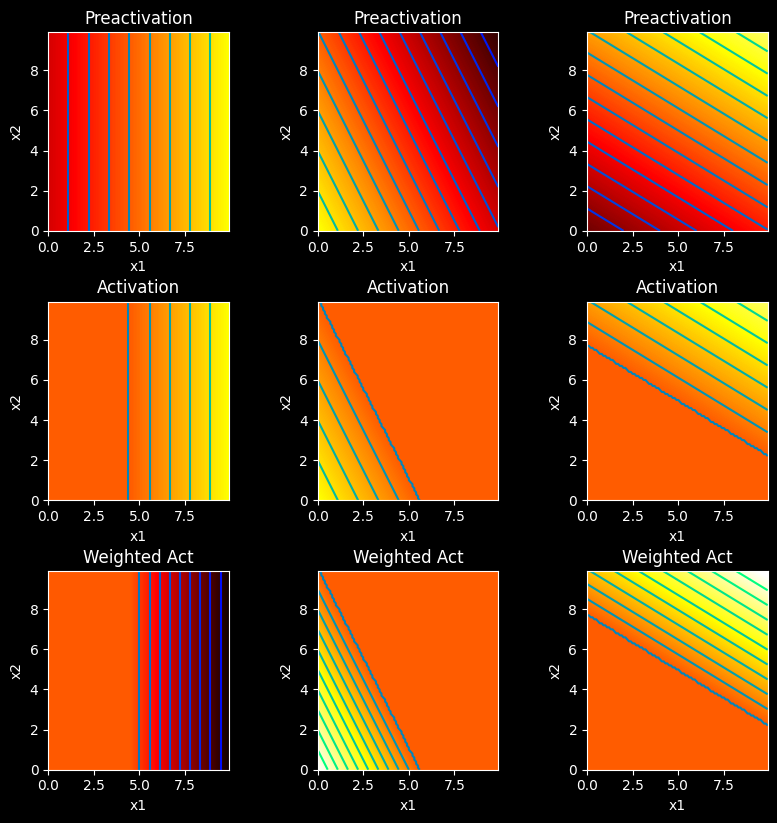

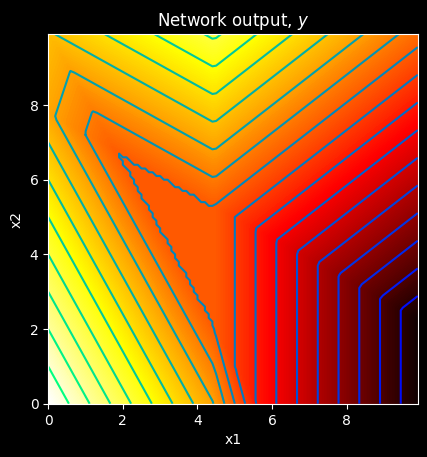

In [56]:
import numpy as np 

# Now lets define some parameters and run the neural network
theta_10 =  -4.0 ;  theta_11 = 0.9; theta_12 = 0.0
theta_20 =  5.0  ; theta_21 = -0.9 ; theta_22 = -0.5
theta_30 =  -7  ; theta_31 = 0.5; theta_32 = 0.9
phi_0 = 0.0; phi_1 = -2.0; phi_2 = 2.0; phi_3 = 1.5

x1 = np.arange(0.0, 10.0, 0.1)
x2 = np.arange(0.0, 10.0, 0.1)
x1,x2 = np.meshgrid(x1,x2)  # https://www.geeksforgeeks.org/numpy-meshgrid-function/

# We run the neural network for each of these input values
y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3 = \
    shallow_2_1_3(x1,x2, ReLU, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_12, theta_20, theta_21, theta_22, theta_30, theta_31, theta_32)
# And then plot it
plot_neural_2_inputs(x1,x2, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3)